# Notebook to visualize results on the test set

In [19]:
import pandas as pd
import seaborn as sns
from pathlib import Path
from matplotlib import pyplot as plt

sns.set_theme()

In [20]:
results_file = Path(
    "../scripts/endovis/endo17/results/Oct12_19.56.33_EndoVis17_Binary_3000.pth_IoUs.json"
)
results_file.is_file()

True

In [21]:
# read the results file into a pandas dataframe
df = pd.read_json(results_file)
df.head()

,Oct12_19.56.33_EndoVis17_Binary_3000.pth
instrument_dataset_09,0.912617
instrument_dataset_10,0.930978


In [22]:
# clean the column names to only contain the last part of the path
df.columns = df.columns.str.split("_").str[-1]
df.columns = df.columns.str.split(".").str[0]
df.head()

,3000
instrument_dataset_09,0.912617
instrument_dataset_10,0.930978


## Plot of average score per model

Text(0, 0.5, 'Average IoU across all videos')

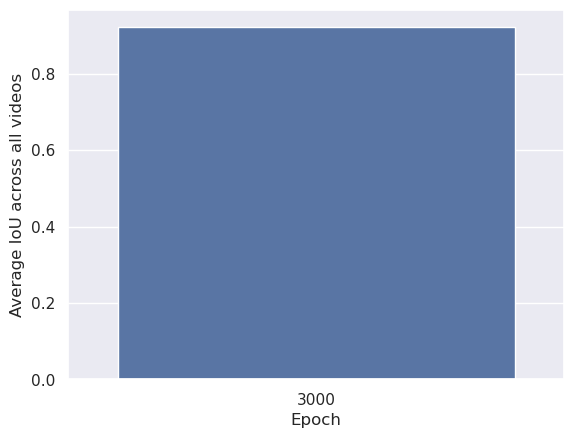

In [23]:
# bar plot of the mean IoU for each column
mean_iou = df.mean()
sns.barplot(x=mean_iou.index, y=mean_iou.values)
plt.xlabel("Epoch")
plt.ylabel("Average IoU across all videos")

## Plot scores per video for a single model

Text(0.5, 1.0, 'Performance of model 3000 on test subset')

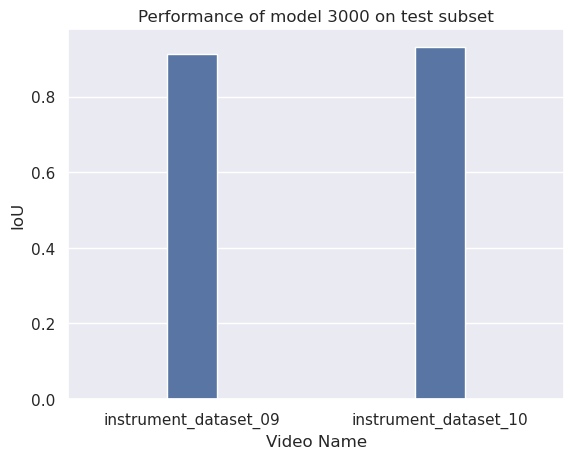

In [25]:
model_name = "3000"
model_scores = df[model_name]

sns.barplot(x=model_scores.index, y=model_scores.values, width=0.2)
plt.xlabel("Video Name")
plt.ylabel("IoU")
plt.title(f"Performance of model {model_name} on test subset")